# 🛟 Fault-Tolerant Training at Scale

[Sam Foreman](https://samforeman.me)
(\[[ALCF](https://alcf.anl.gov/about/people/sam-foreman)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
2026-07-22

> **Authors**
>
> Written by [Sam Foreman](https://samforeman.me) for the [Intro to HPC
> Bootcamp](https://intro-hpc-bootcamp.alcf.anl.gov/).

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/03-advanced-llms/2-fault-tolerant-training/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/content/03-advanced-llms/2-fault-tolerant-training/index.qmd)

## 👋 Failures are the norm, not the exception

In [\[02.1\] Distributed
Training](../../01-neural-networks/5-distributed-training/index.qmd) you
learned that a collective op only completes when **every** rank
participates — one silent straggler and the whole job waits
*indefinitely*. That fragility is exactly the problem at scale.

Do the arithmetic. A single GPU has a mean time between failures (MTBF)
measured in years. But a job on **thousands** of GPUs running for
**weeks** is a product of thousands of those probabilities — so the
*job’s* MTBF collapses to **hours**. Meta reported [hundreds of
interruptions](https://arxiv.org/abs/2407.21783) during Llama-3 405B
pretraining; roughly 78% were hardware issues, the majority GPU-related.
At that scale a network link flapping, a straggler or dead node, a
shared-filesystem stall, an ECC memory error, or an out-of-memory (OOM)
spike is not an *if* — it *will* happen, probably several times before
your run finishes.

So “training at scale” is really two jobs: (1) make the model learn, and
(2) make the run **survive** the failures that are guaranteed to
interrupt it. This lab is about job #2. The contract is simple:

> **Checkpoint often enough that a crash costs minutes, not days — and
> make restart automatic so a human doesn’t have to babysit the run at
> 3am.**

We’ll follow the usual **toy → real → scale** path: a checkpoint/restart
loop that really runs on your laptop, a taxonomy of real production
failure modes with their actual log signatures, then
`ezpz launch --auto-retry`, which turns “babysit-the-run-at-3am” into a
flag.

## ① A toy that really runs

The whole idea of fault tolerance rests on one primitive: **you can stop
a training run at any step and resume it exactly where it left off.**
Let’s build that primitive from scratch — small enough to run on a CPU
in under a second.

The run below trains a tiny model, checkpoints every few steps,
**crashes on purpose** partway through, and then restarts — picking the
step counter up right where the crash left it.

In [2]:
import os
import tempfile
import numpy as np
import torch
import torch.nn as nn

CKPT_DIR = tempfile.mkdtemp(prefix="ft-toy-")
CKPT_PATH = os.path.join(CKPT_DIR, "latest.pt")
CKPT_EVERY = 5     # save a checkpoint every N steps
TOTAL_STEPS = 20   # train this many steps in total


def build():
    """A fresh (model, optimizer) pair — identical construction every time."""
    torch.manual_seed(0)  # deterministic *init*; RNG *state* is checkpointed below
    model = nn.Linear(8, 1)
    opt = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    return model, opt


def save_checkpoint(path, model, opt, step):
    """Atomic checkpoint: model + optimizer + step + RNG state."""
    payload = {
        "step": step,
        "model": model.state_dict(),
        "optim": opt.state_dict(),           # momentum buffers live here!
        "torch_rng": torch.get_rng_state(),  # so data order resumes identically
        "numpy_rng": np.random.get_state(),
    }
    tmp = path + ".tmp"
    torch.save(payload, tmp)   # 1. write to a temp file
    os.replace(tmp, path)      # 2. atomic rename -> never a half-written "latest.pt"


def load_checkpoint(path, model, opt):
    """Restore everything and return the step to resume *after*."""
    # weights_only=False because we saved non-tensor state (NumPy RNG) and we
    # trust our own checkpoint. Only ever do this for files YOU wrote.
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model"])
    opt.load_state_dict(ckpt["optim"])
    torch.set_rng_state(ckpt["torch_rng"])
    np.random.set_state(ckpt["numpy_rng"])
    return ckpt["step"]


def train(crash_at=None):
    model, opt = build()
    start = 0
    if os.path.exists(CKPT_PATH):                 # <-- the restart branch
        start = load_checkpoint(CKPT_PATH, model, opt)
        print(f"  ↩︎  resumed from checkpoint at step {start}")
    else:
        print("  🌱  no checkpoint found; starting fresh at step 0")

    for step in range(start, TOTAL_STEPS):
        x = torch.randn(16, 8)                     # fake batch
        loss = ((model(x) - x.sum(dim=1, keepdim=True)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        next_step = step + 1

        if next_step % CKPT_EVERY == 0:
            save_checkpoint(CKPT_PATH, model, opt, next_step)
            print(f"  💾 step {next_step:>2}  loss={loss.item():.4f}  (checkpoint saved)")

        if crash_at is not None and next_step == crash_at:
            raise RuntimeError(f"💥 simulated node failure at step {next_step}")


print("── Run #1: train until the (simulated) crash ──")
try:
    train(crash_at=13)
except RuntimeError as e:
    print(f"  {e}\n  ...process died. The scheduler (or a human) relaunches it.\n")

print("── Run #2: relaunch the SAME command ──")
train()   # no code change — it just finds latest.pt and resumes
print("\n✅ Training finished. The step counter never restarted from 0.")

── Run #1: train until the (simulated) crash ──
  🌱  no checkpoint found; starting fresh at step 0
  💾 step  5  loss=1.8629  (checkpoint saved)
  💾 step 10  loss=3.4365  (checkpoint saved)
  💥 simulated node failure at step 13
  ...process died. The scheduler (or a human) relaunches it.

── Run #2: relaunch the SAME command ──
  ↩︎  resumed from checkpoint at step 10
  💾 step 15  loss=3.0858  (checkpoint saved)
  💾 step 20  loss=6.0969  (checkpoint saved)

✅ Training finished. The step counter never restarted from 0.

Notice what made the restart *seamless*: **Run #2 is the exact same call
as Run #1.** The code doesn’t know or care that it crashed — it just
checks for a checkpoint on startup. That is the whole checkpoint/restart
contract, and it’s what every fault-tolerance system below is built on.

> **Save the optimizer and RNG state, not just the weights**
>
> A checkpoint of `model.state_dict()` alone is a **subtle bug**. Two
> things break if you only save weights:
>
> - **Optimizer state.** Adam’s first/second moments and SGD’s momentum
>   buffers live in `opt.state_dict()`. Drop them and the optimizer
>   restarts cold — your loss spikes and effective learning rate is
>   wrong for hundreds of steps after every restart. On a run that
>   restarts a dozen times, that adds up.
> - **RNG state.** Save `torch.get_rng_state()` (and NumPy/CUDA RNG) so
>   data shuffling, dropout, and augmentation resume *identically*.
>   Otherwise “resume” silently replays or skips samples.

> **⚛️ Why the atomic rename matters**
>
> `save_checkpoint` writes to `latest.pt.tmp` and then `os.replace()`s
> it into place. `os.replace` is an **atomic** rename on POSIX
> filesystems: `latest.pt` is *always* either the old complete
> checkpoint or the new complete one — never a half-written file.
> Without this, a crash *during* the save (very possible when the node
> is dying) leaves a truncated `latest.pt`, and your restart fails to
> load the very thing meant to save you. Write-then-rename is the
> cheapest insurance in all of HPC.

## ② The real thing: failure modes and their signatures

At scale, “the node crashed” is rarely what you actually see. You see a
wall of tracebacks from *innocent* ranks that were mid-collective when
one peer vanished. The skill is reading the log to find the **one** node
that actually died. Here is the taxonomy of what goes wrong on a large
run:

| Failure mode | What triggers it | What you see in the log |
|------------------------|------------------------|------------------------|
| **Network flap** | HSN/InfiniBand link resets; a NIC drops | `gloo`/NCCL `Connection closed by peer`, collective timeouts |
| **Shared-FS stall** | Lustre/NFS MDS overload at checkpoint time | job hangs with *no output*; ranks blocked in `torch.save` |
| **Straggler / dead node** | Node-local daemon hangs; hardware fault | PALS `shepherd died from signal 9`, then a cascade of peer errors |
| **ECC / GPU error** | Uncorrectable memory error, XID fault | `UR_RESULT_ERROR_OUT_OF_RESOURCES`, Xid in `dmesg`, rank aborts |
| **OOM** | Activation/KV-cache spike, memory fragmentation | `torch.cuda.OutOfMemoryError` / `OutOfMemoryError` |

Common at-scale failure modes and their log signatures
{.table-responsive .table-striped .table-hover}

The failover scraper in `ezpz` matches these **real** signatures — these
are lines pulled from Aurora/Sunspot postmortems, not invented examples:

``` bash
# PALS shepherd kill — the node-local daemon went non-responsive.
# Aurora's most common hardware failure. The hostname prefix IS the culprit:
x4718c3s2b0n0.hsn.cm.aurora.alcf.anl.gov: shepherd died from signal 9

# gloo TCP peer-connection closed — one dead node, many ranks report it.
# ezpz reverse-resolves the IP -> hostname:
RuntimeError: [../third_party/gloo/.../pair.cc:534] Connection closed by peer [10.0.0.42]:47123

# Intel XPU (oneAPI/Level-Zero) out-of-resources — GPU/ECC fault:
RuntimeError: UR_RESULT_ERROR_OUT_OF_RESOURCES

# Classic OOM:
torch.cuda.OutOfMemoryError: CUDA out of memory. Tried to allocate 2.00 GiB
```

> **Not every scary line names the guilty node**
>
> When a node dies, `mpiexec` sprays `rank N died from signal 11`
> (SIGSEGV) or `signal 15` (SIGTERM) from **every** rank that was torn
> down as collateral. The `ezpz` scraper **deliberately ignores** those
> cascading `signal {11,15}` lines — tagging them would swap out an
> *innocent* node and leave the real culprit in place. (This is a real
> postmortem lesson: job 8466848 had rank 1304 die from signal 11 as a
> downstream effect of a `std::bad_alloc` on a *different* node.) The
> signatures worth acting on are the *primary* ones above:
> `shepherd died from signal 9`, `Connection closed by peer`,
> `UR_RESULT_ERROR_OUT_OF_RESOURCES`, `OutOfMemoryError`.

### Checkpointing a model that no longer fits on one GPU

The toy saved one `.pt` file from one process. But once you’re using
FSDP or 3D parallelism (from
[\[02.1\]](../../01-neural-networks/5-distributed-training/index.qmd)),
model + optimizer state is **sharded across hundreds of ranks** —
funneling it all to rank 0 to write one giant file is slow and often
OOMs.

The answer is **Distributed Checkpointing (DCP)** —
[`torch.distributed.checkpoint`](https://pytorch.org/docs/stable/distributed.checkpoint.html).
Each rank writes **its own shard** in parallel, and DCP can **reshard on
load**, so a run saved on 512 GPUs can resume onto 256. `torchtitan`
uses DCP by default (`--checkpoint.enable --checkpoint.interval N`, see
[\[03.1\] Pretraining at Scale](../1-pretraining-at-scale/index.qmd)).

In [3]:
# Sketch of sharded save/load with PyTorch DCP (display-only).
import torch.distributed.checkpoint as dcp

state = {"model": model.state_dict(), "optim": optim.state_dict(), "step": step}
# Every rank writes its own shard, in parallel, into ckpt/step-1000/:
dcp.save(state, checkpoint_id=f"ckpt/step-{step}")

# On restart (possibly with a *different* world size), DCP reshards to fit:
dcp.load(state, checkpoint_id="ckpt/step-1000")

> **⚠️ The shared filesystem is a failure mode too**
>
> Lustre/GPFS is a **shared, contended** resource. If all N ranks call
> `torch.save` to the same directory at the same step, you hammer the
> metadata server (MDS) and can *induce* the very stall you’re trying to
> survive — the job goes silent with no error at all. Mitigations: use
> **DCP** (parallel shard writes) rather than gather-to-rank-0;
> **stripe** large checkpoint files across OSTs ([Lustre
> striping](https://wiki.lustre.org/Configuring_Lustre_File_Striping));
> stagger or throttle writers; and keep only the last few checkpoints so
> you don’t DOS your own filesystem. A silent hang with a live W&B
> heartbeat but *frozen* training metrics is the classic signature — and
> it’s why the launcher below has an **idle-output watchdog**.

## ③ Scale it up: `ezpz launch --auto-retry`

Knowing *how* to restart is only half the battle — at 3am, someone (or
something) has to actually notice the crash, figure out which node was
bad, throw it out, and relaunch. `ezpz launch --auto-retry` does all of
that in a loop.

First, the usual one-time environment setup (see the [track
intro](../index.qmd#one-time-setup)):

``` bash
source <(curl -fsSL https://bit.ly/ezpz-utils) && ezpz_setup .venv
uv pip install git+https://github.com/saforem2/ezpz
ezpz test   # confirm device / backend / world size
```

Then launch a run under the failover loop. Because your training script
already implements the checkpoint/restart contract from
<a href="#sec-toy" class="quarto-xref">Section 2</a>, a relaunch on
fresh nodes just resumes from `latest.pt`:

``` bash
# Request MORE nodes than you need to train on: the extras are spares.
# --auto-retry requires -n (nproc) to be set explicitly.
ezpz launch \
    --auto-retry \
    --spare-nodes auto \
    --max-failover-retries 5 \
    --timeout 1800 \
    -n 96 \
    python3 -m ezpz.examples.test \
        --max-iters 50000 \
        --ckpt-dir /path/to/checkpoints \
        --ckpt-interval 500
```

What each flag does:

- **`--auto-retry`** — splits your allocation into an **active**
  training set and a **spare** pool, then runs your command in a loop.
  On a non-zero exit it *scrapes the log* for the bad-node signatures
  from <a href="#sec-real" class="quarto-xref">Section 3</a>, **swaps
  the guilty node(s) out for spares**, and relaunches. It keeps going
  until the run **succeeds**, hits the **walltime**, or **runs out of
  spares**.
- **`--spare-nodes auto`** — `auto` uses every node beyond the `-n`
  training set as a spare (`total − active`); or pass an explicit
  integer `N`.
- **`--timeout SECONDS`** — an **idle-*output* watchdog**, not a total
  time limit. If the job produces *no stdout* for this long, the
  launcher assumes a silent collective hang (the shared-FS stall from
  <a href="#sec-real" class="quarto-xref">Section 3</a>), kills it with
  **exit 124**, and treats it as a bad-node failure. It **defaults to
  1800s** when `--auto-retry` is set.
- **`--max-failover-retries N`** — cap on how many times to
  swap-and-retry (default: unbounded, bounded only by walltime and spare
  pool).
- **`--retries N`** — the *simpler* cousin: a plain **process-level**
  re-run of the same command N times, with **no** log scraping or node
  swapping. It is **mutually exclusive** with `--auto-retry` (use one or
  the other).

> **🧠 A smarter guard than a retry counter**
>
> `--auto-retry` also bails early on `STUCK_PRE_TRAINING`: if **two
> consecutive** attempts produce zero `step=` progress markers, the
> problem is a code/config bug (bad dataset path, wrong shapes), not a
> bad node — and no amount of node-swapping will fix it. This stops the
> loop from burning your entire spare pool relaunching a run that was
> never going to train.

### The failover loop

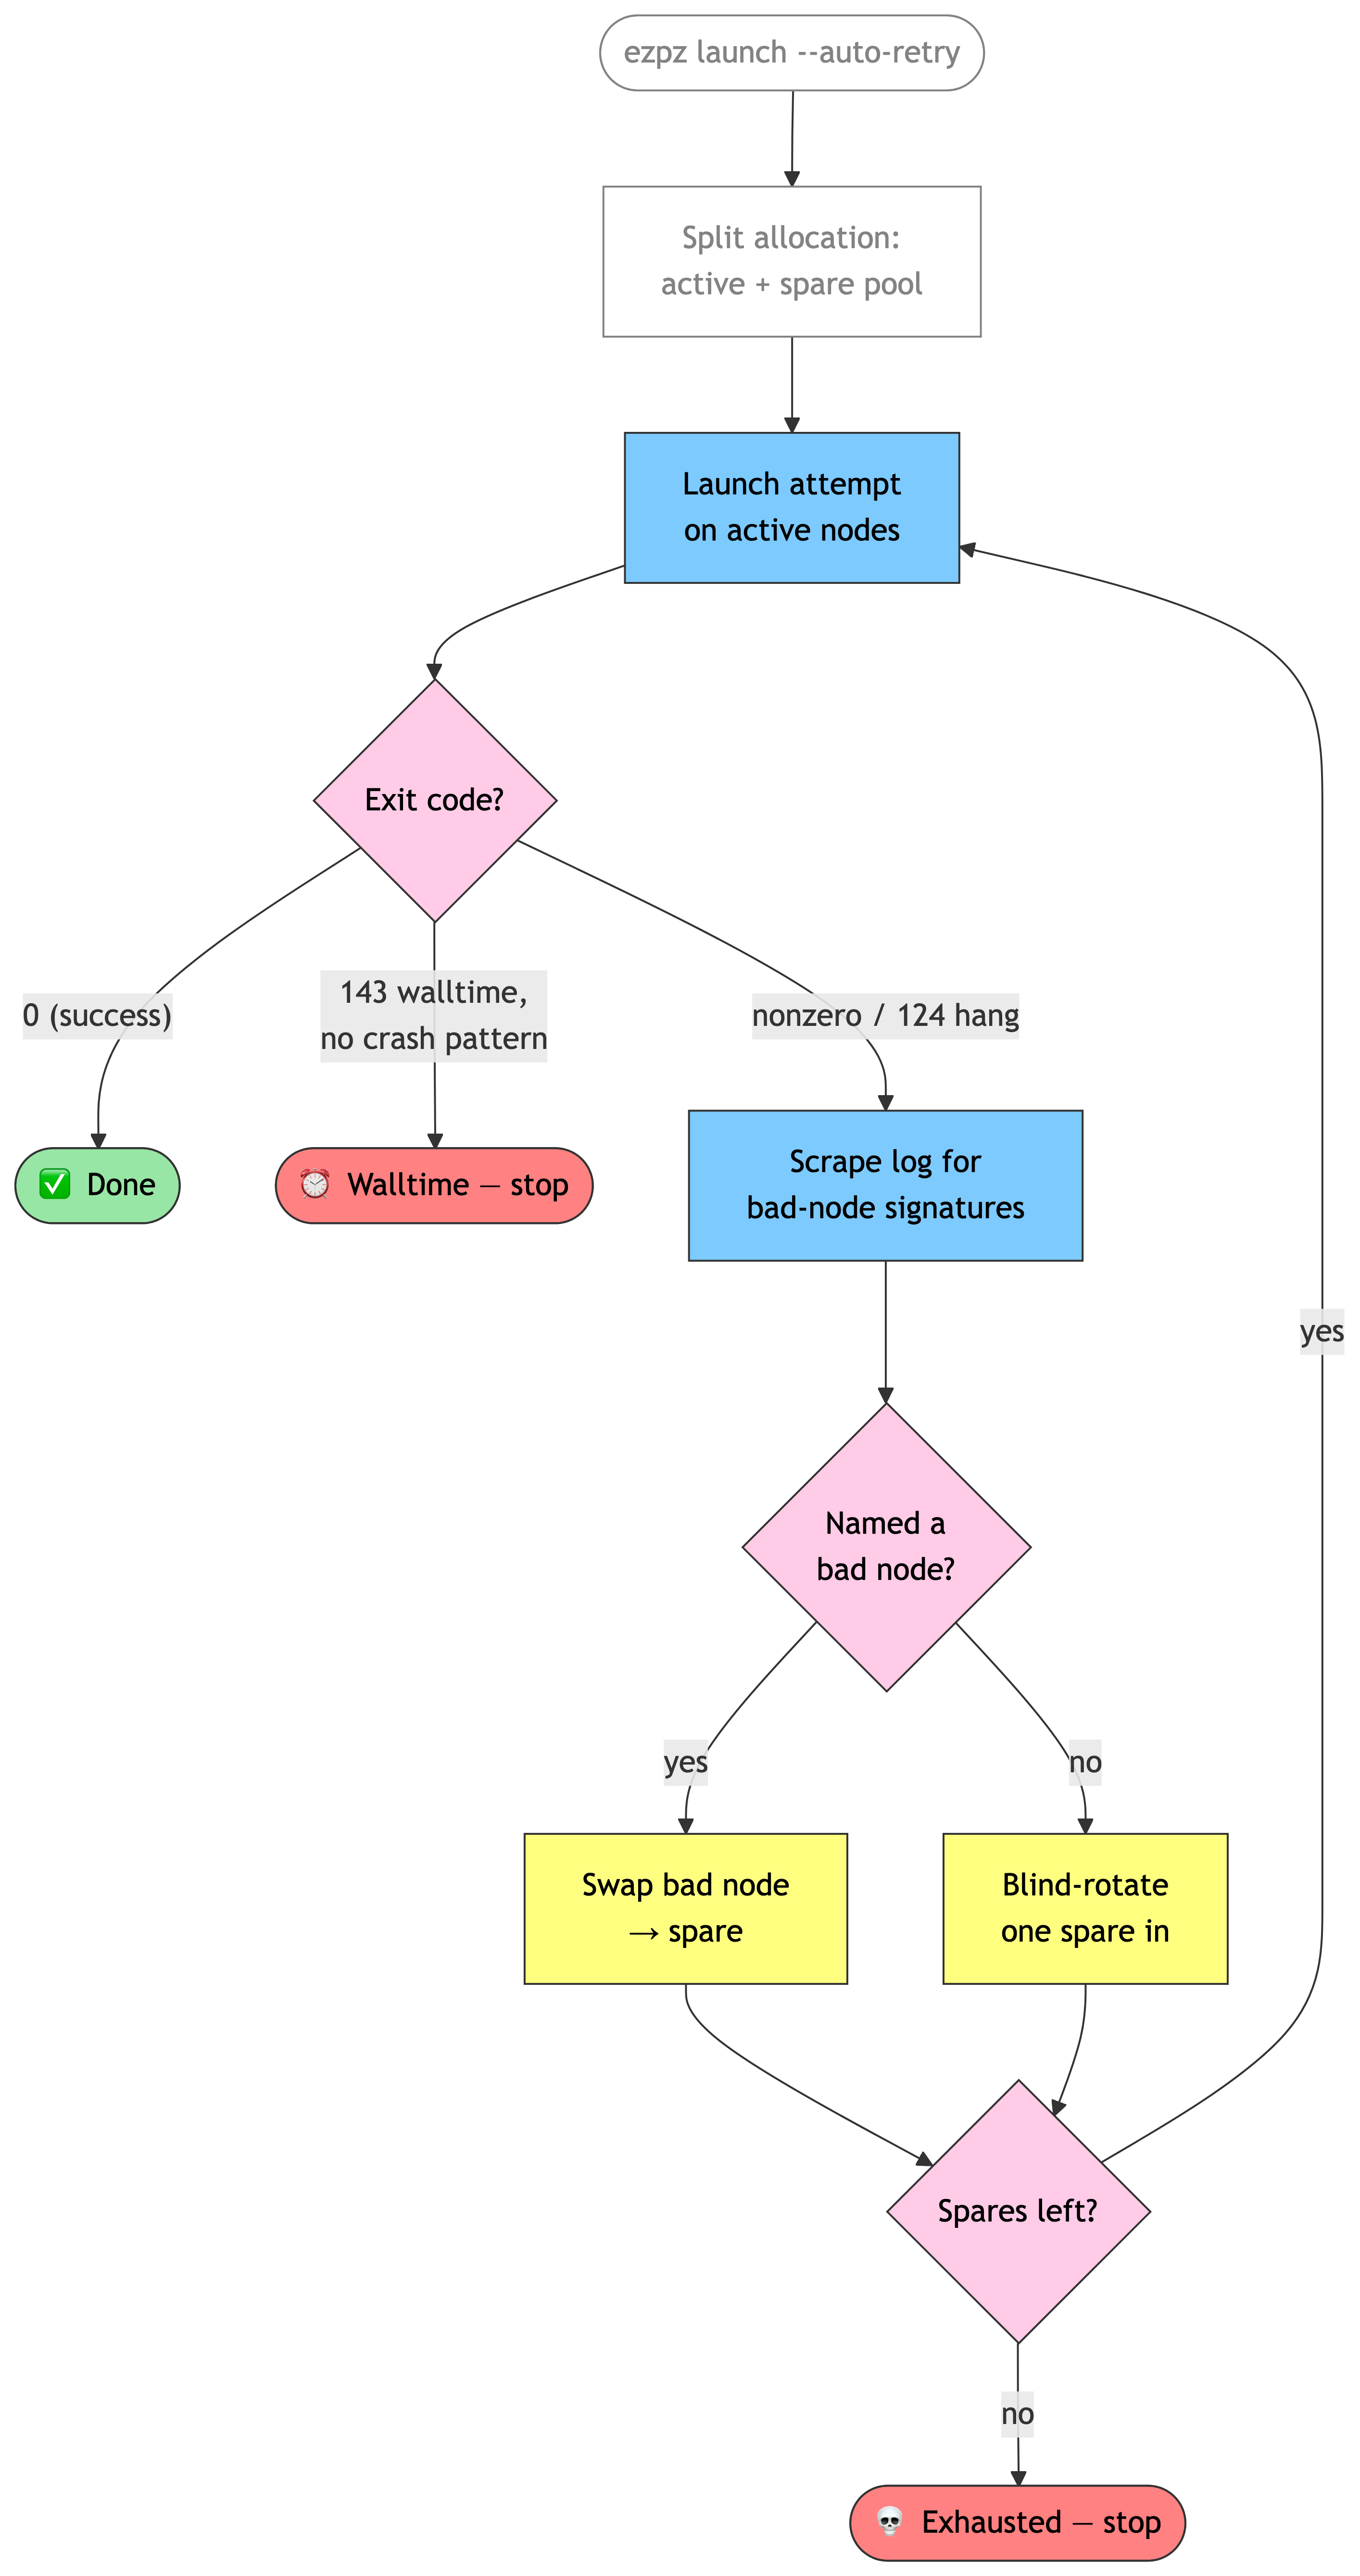

Every iteration writes an `attempt-N.log` and appends any culprit to
`bad_nodes.txt`, and the loop always ends with a single
`FAILOVER STOP: <reason>` line (`success` / `walltime` / `exhausted` /
`stuck_pre_training`) so a postmortem `grep` always lands on the
verdict.

> **Can’t put ezpz launch at the top? Use the bash lib**
>
> Some job scripts (e.g. a `torchtitan` launcher you don’t own) can’t be
> wrapped by `ezpz launch`. For those, `ezpz` ships the same logic as a
> sourceable shell library,
> [`src/ezpz/bin/failover.sh`](https://github.com/saforem2/ezpz/blob/main/src/ezpz/bin/failover.sh):
>
> ``` bash
> source "$(python3 -c 'import ezpz, pathlib; print(pathlib.Path(ezpz.configs.BIN_DIR) / "failover.sh")')"
> failover_init "$NHOSTS_TRAIN"    # split PBS_NODEFILE -> active + spare
> failover_yeet_all                # broadcast the venv to ALL nodes (spares included)
> failover_run ezpz launch python3 -m torchtitan.train --job.config_file <toml>
> ```
>
> It scrapes the same signatures, swaps spares the same way, and honors
> the same `FAILOVER_IDLE_TIMEOUT` (default 1800s) watchdog.

## 🎒 Homework

Prove that your training survives a crash. Submit **proof of a resumed
run**:

1.  Take a checkpointing training script — the
    <a href="#sec-toy" class="quarto-xref">Section 2</a> loop is fine,
    or `python3 -m ezpz.examples.test` with a `--ckpt-dir` /
    `--ckpt-interval`, or your own — and launch it so it checkpoints
    every N steps:

    ``` bash
    ezpz launch -n <N> python3 -m ezpz.examples.test \
        --max-iters 2000 --ckpt-dir ./ckpts --ckpt-interval 100
    ```

2.  **Kill it** partway through (Ctrl-C, `scancel`/`qdel`, or just let
    the simulated crash fire) *after* at least one checkpoint has been
    written.

3.  **Relaunch the exact same command** and confirm the run **resumes**
    — the step counter must continue from the last checkpoint, not
    restart at 0.

4.  (Optional stretch) Run it under
    `ezpz launch --auto-retry --spare-nodes auto` and find the
    `FAILOVER STOP: <reason>` line and the `attempt-N.log` files.

Where *proof* can be any of:

- The contents printed to your terminal showing
  `resumed from checkpoint at step K` and the counter continuing past it
- A path to a logfile on the ALCF/NERSC filesystems containing the
  resumed run
- A screenshot of the terminal output or a W&B chart where loss
  **continues** (not resets) across the restart
- A url to a W&B Run or Report
- etc.

The point: a run that resumes cleanly from a checkpoint is a run that
can survive a multi-week job on thousands of GPUs.

> **🔬 At DeepSeek-V3 / Llama-3 scale…**
>
> This isn’t academic. Llama-3 405B pretraining logged [**466 job
> interruptions** over 54 days](https://arxiv.org/abs/2407.21783) — ~78%
> hardware, mostly GPU faults — and still sustained \>90% effective
> training time. The only reason that’s possible is aggressive
> checkpointing plus automated detect-swap-resume: exactly the loop you
> just ran in miniature.

------------------------------------------------------------------------

*Last updated: 2026-07-22*